# Anomalous Transaction Detection for Financial Dark Pools
## CS667 Project 3 - Complete Implementation

This notebook implements the complete anomaly detection pipeline as described in the Financial Anomalies paper, combining:
- Statistical analysis using Benford's Law
- Gaussian Mixture Model (GMM) clustering
- Isolation Forest anomaly detection
- Progressive thresholding methodology
- Comprehensive evaluation and visualization

## 1. Data Loading and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
from utils import targetEncode, labelEncode, oneHotEncode

# Set style for visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Load the engineered data
print("Loading engineered financial transaction data...")
engData = pd.read_csv('./data/eng_data.csv')
# engData = pd.read_csv('./data/eng_data.csv')

print(f"Dataset shape: {engData.shape}")
print(f"Date range: {engData['Timestamp'].min()} to {engData['Timestamp'].max()}")
print("\nFirst few rows:")
print(engData.head())

print("\nDataset Info:")
print(engData.info())

print("\nSummary Statistics:")
print(engData.describe())

Loading engineered financial transaction data...
Dataset shape: (400000, 15)
Date range: 2023-01-01 03:00:00 to 2023-12-31 19:52:00

First few rows:
             Timestamp  TransactionID  AccountID      Amount Merchant  \
0  2023-01-01 06:03:00         308153          6    99999.99        J   
1  2023-01-01 06:03:00         269299          3   105628.04        J   
2  2023-01-01 06:16:00         331884         13  1042101.75        B   
3  2023-01-01 06:41:00          66564         14   297872.43        B   
4  2023-01-01 06:55:00          38295          2   334513.99        J   

  TransactionType       Location  Year  Quarter  Month Day_Of_Week  \
0      Withdrawal       New York  2023        1      1      Sunday   
1        Transfer       New York  2023        1      1      Sunday   
2        Purchase  San Francisco  2023        1      1      Sunday   
3        Purchase       New York  2023        1      1      Sunday   
4        Transfer       New York  2023        1      1      Su

In [3]:
# Data preprocessing and feature engineering
def preprocess_data(data):
    """
    Complete data preprocessing pipeline for anomaly detection
    """
    # Create a copy to avoid modifying original
    processed_data = data.copy()
    
    # Convert timestamp to datetime if it's not already
    processed_data['Timestamp'] = pd.to_datetime(processed_data['Timestamp'])
    
    # Target encode categorical features
    categorical_features = ['TransactionType', 'Location', 'Day_Of_Week', 'Merchant']
    processed_data = targetEncode(
        data=processed_data, 
        encodeFeatures=categorical_features, 
        targetFeature='Amount'
    )
    
    # Set timestamp as index for time-series operations
    processed_data = processed_data.set_index('Timestamp')
    
    # Select features for anomaly detection (exclude IDs)
    feature_columns = [
        'Amount', 'TransactionType', 'Location', 'Merchant',
        'Year', 'Quarter', 'Month', 'Day_Of_Week', 
        'Day_Of_Month', 'Day_Of_Year', 'Hour', 'Minute'
    ]
    
    # Keep only selected features
    available_features = [col for col in feature_columns if col in processed_data.columns]
    processed_features = processed_data[available_features]
    
    print(f"Selected {len(available_features)} features for anomaly detection:")
    print(available_features)
    
    return processed_features

# Preprocess the data
processed_data = preprocess_data(engData)
print(f"\nProcessed data shape: {processed_data.shape}")
print("\nProcessed data sample:")
print(processed_data.head())

Selected 12 features for anomaly detection:
['Amount', 'TransactionType', 'Location', 'Merchant', 'Year', 'Quarter', 'Month', 'Day_Of_Week', 'Day_Of_Month', 'Day_Of_Year', 'Hour', 'Minute']

Processed data shape: (400000, 12)

Processed data sample:
                         Amount TransactionType    Location    Merchant  Year  \
Timestamp                                                                       
2023-01-01 06:03:00    99999.99       171882.45   172351.44  204317.475  2023   
2023-01-01 06:03:00   105628.04      172235.295   172351.44  204317.475  2023   
2023-01-01 06:16:00  1042101.75       173219.18  172143.395   324875.01  2023   
2023-01-01 06:41:00   297872.43       173219.18   172351.44   324875.01  2023   
2023-01-01 06:55:00   334513.99      172235.295   172351.44  204317.475  2023   

                     Quarter  Month Day_Of_Week  Day_Of_Month  Day_Of_Year  \
Timestamp                                                                    
2023-01-01 06:03:00       

## 2. Benford's Law Statistical Analysis

Performing Benford's Law analysis on complete dataset...


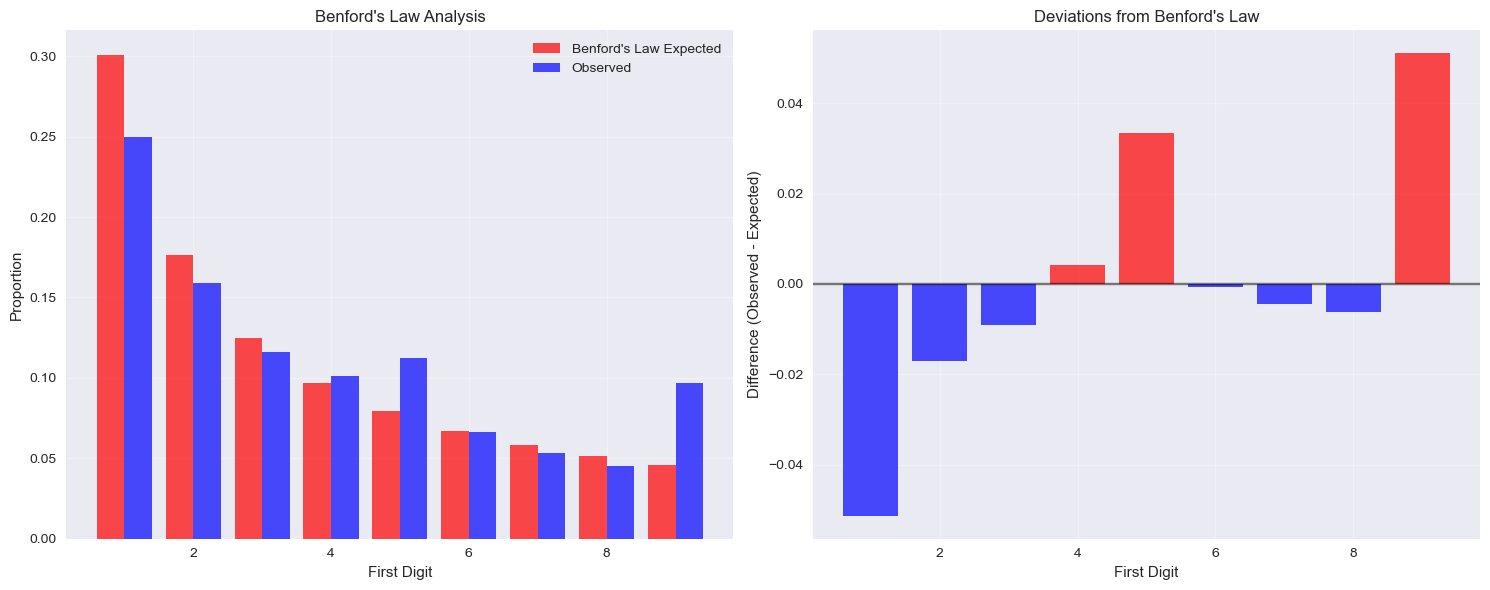


=== Benford's Law Analysis Results ===
Sample size: 400,000
Chi-squared statistic: 33277.3531
P-value: 0.000000
Euclidean distance: 0.0824
Is anomalous (α=0.05): True

⚠️  ALERT: This dataset significantly deviates from Benford's Law!
   Further investigation with advanced clustering is warranted.


In [4]:
def benford_analysis(data, amount_column='Amount', significance_level=0.05):
    """
    Implement Benford's Law analysis for fraud detection
    """
    # Extract first digits from amounts
    amounts = data[amount_column].dropna()
    first_digits = amounts.astype(str).str[0].astype(int)
    
    # Calculate observed frequencies
    observed_counts = first_digits.value_counts().sort_index()
    observed_proportions = observed_counts / len(first_digits)
    
    # Calculate expected Benford proportions
    benford_proportions = pd.Series(
        [np.log10(1 + 1/d) for d in range(1, 10)], 
        index=range(1, 10)
    )
    
    # Ensure both series have the same index
    for digit in range(1, 10):
        if digit not in observed_proportions.index:
            observed_proportions[digit] = 0
    observed_proportions = observed_proportions.sort_index()
    
    # Calculate chi-squared statistic
    expected_counts = benford_proportions * len(first_digits)
    chi_squared = np.sum((observed_counts - expected_counts)**2 / expected_counts)
    
    # Calculate p-value (8 degrees of freedom for 9 categories - 1)
    p_value = 1 - stats.chi2.cdf(chi_squared, df=8)
    
    # Calculate Euclidean distance
    euclidean_distance = np.sqrt(np.sum((observed_proportions - benford_proportions)**2))
    
    # Determine if anomalous
    is_anomalous = p_value < significance_level
    
    return {
        'observed_proportions': observed_proportions,
        'benford_proportions': benford_proportions,
        'chi_squared': chi_squared,
        'p_value': p_value,
        'euclidean_distance': euclidean_distance,
        'is_anomalous': is_anomalous,
        'sample_size': len(first_digits)
    }

def visualize_benford_analysis(benford_results):
    """
    Visualize Benford's Law analysis results
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot distributions
    digits = range(1, 10)
    ax1.bar([d - 0.2 for d in digits], benford_results['benford_proportions'], 
            width=0.4, label='Benford\'s Law Expected', alpha=0.7, color='red')
    ax1.bar([d + 0.2 for d in digits], benford_results['observed_proportions'], 
            width=0.4, label='Observed', alpha=0.7, color='blue')
    ax1.set_xlabel('First Digit')
    ax1.set_ylabel('Proportion')
    ax1.set_title('Benford\'s Law Analysis')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot differences
    differences = benford_results['observed_proportions'] - benford_results['benford_proportions']
    colors = ['red' if d > 0 else 'blue' for d in differences]
    ax2.bar(digits, differences, color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_xlabel('First Digit')
    ax2.set_ylabel('Difference (Observed - Expected)')
    ax2.set_title('Deviations from Benford\'s Law')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical results
    print(f"\n=== Benford's Law Analysis Results ===")
    print(f"Sample size: {benford_results['sample_size']:,}")
    print(f"Chi-squared statistic: {benford_results['chi_squared']:.4f}")
    print(f"P-value: {benford_results['p_value']:.6f}")
    print(f"Euclidean distance: {benford_results['euclidean_distance']:.4f}")
    print(f"Is anomalous (α=0.05): {benford_results['is_anomalous']}")
    
    if benford_results['is_anomalous']:
        print("\n⚠️  ALERT: This dataset significantly deviates from Benford's Law!")
        print("   Further investigation with advanced clustering is warranted.")
    else:
        print("\n✅ This dataset appears to follow Benford's Law within normal bounds.")

# Perform Benford's Law analysis on the complete dataset
print("Performing Benford's Law analysis on complete dataset...")
benford_results = benford_analysis(processed_data)
visualize_benford_analysis(benford_results)

## 3. Advanced Clustering Algorithms

In [5]:
class AdvancedGMM:
    """
    Enhanced Gaussian Mixture Model for anomaly detection
    """
    def __init__(self, n_components=10, covariance_type='full', random_state=42):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.random_state = random_state
        self.gmm = None
        self.scaler = StandardScaler()
        self.is_fitted = False
        
    def fit(self, X):
        """
        Fit the GMM model to training data
        """
        # Scale the data
        X_scaled = self.scaler.fit_transform(X)
        
        # Find optimal number of components using BIC
        bic_scores = []
        aic_scores = []
        component_range = range(1, min(21, X.shape[0] // 10))
        
        for n_comp in component_range:
            gmm_temp = GaussianMixture(
                n_components=n_comp, 
                covariance_type=self.covariance_type,
                random_state=self.random_state
            )
            gmm_temp.fit(X_scaled)
            bic_scores.append(gmm_temp.bic(X_scaled))
            aic_scores.append(gmm_temp.aic(X_scaled))
        
        # Select optimal components (minimum BIC)
        optimal_components = component_range[np.argmin(bic_scores)]
        
        print(f"Optimal number of GMM components (by BIC): {optimal_components}")
        
        # Fit final model
        self.gmm = GaussianMixture(
            n_components=optimal_components,
            covariance_type=self.covariance_type,
            random_state=self.random_state
        )
        self.gmm.fit(X_scaled)
        self.is_fitted = True
        
        return self
    
    def predict_anomalies(self, X, threshold_percentile=5):
        """
        Predict anomalies based on likelihood threshold
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction")
        
        X_scaled = self.scaler.transform(X)
        
        # Calculate log-likelihood scores
        log_likelihood = self.gmm.score_samples(X_scaled)
        
        # Calculate anomaly threshold
        threshold = np.percentile(log_likelihood, threshold_percentile)
        
        # Classify anomalies
        anomalies = (log_likelihood < threshold).astype(int)
        
        return {
            'anomaly_scores': -log_likelihood,  # Higher scores = more anomalous
            'log_likelihood': log_likelihood,
            'anomalies': anomalies,
            'threshold': threshold
        }

class AdvancedIsolationForest:
    """
    Enhanced Isolation Forest for anomaly detection
    """
    def __init__(self, contamination=0.1, n_estimators=200, random_state=42):
        self.contamination = contamination
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.isolation_forest = None
        self.scaler = StandardScaler()
        self.is_fitted = False
        
    def fit(self, X):
        """
        Fit the Isolation Forest model
        """
        # Scale the data
        X_scaled = self.scaler.fit_transform(X)
        
        # Fit Isolation Forest
        self.isolation_forest = IsolationForest(
            contamination=self.contamination,
            n_estimators=self.n_estimators,
            random_state=self.random_state
        )
        self.isolation_forest.fit(X_scaled)
        self.is_fitted = True
        
        return self
    
    def predict_anomalies(self, X):
        """
        Predict anomalies using Isolation Forest
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction")
        
        X_scaled = self.scaler.transform(X)
        
        # Get anomaly scores and predictions
        anomaly_scores = self.isolation_forest.decision_function(X_scaled)
        anomalies = self.isolation_forest.predict(X_scaled)
        anomalies = np.where(anomalies == -1, 1, 0)  # Convert to 0/1
        
        # Calculate threshold from decision function scores
        threshold = np.percentile(anomaly_scores, (1 - self.contamination) * 100)
        
        return {
            'anomaly_scores': -anomaly_scores,  # Higher scores = more anomalous
            'anomalies': anomalies,
            'threshold': threshold
        }

## 4. Progressive Thresholding Pipeline

In [6]:
class ProgressiveAnomalyDetector:
    """
    Complete progressive thresholding anomaly detection pipeline
    """
    def __init__(self, 
                 benford_threshold=0.05,
                 initial_gmm_threshold=5,
                 initial_if_contamination=0.05,
                 threshold_step=0.02,
                 max_iterations=10,
                 max_removal_percentage=0.75):
        
        self.benford_threshold = benford_threshold
        self.initial_gmm_threshold = initial_gmm_threshold
        self.initial_if_contamination = initial_if_contamination
        self.threshold_step = threshold_step
        self.max_iterations = max_iterations
        self.max_removal_percentage = max_removal_percentage
        
        self.gmm_model = AdvancedGMM()
        self.if_model = AdvancedIsolationForest(contamination=initial_if_contamination)
        
        # Storage for results
        self.iteration_results = []
        self.final_anomalies = None
        self.normal_transactions = None
        
    def detect_anomalies_batch(self, batch_data):
        """
        Progressive anomaly detection on a batch of transactions
        """
        print(f"\n=== Processing batch with {len(batch_data)} transactions ===")
        
        current_data = batch_data.copy()
        removed_indices = set()
        iteration = 0
        
        # Initial Benford's Law check
        benford_result = benford_analysis(current_data)
        print(f"Initial Benford's Law p-value: {benford_result['p_value']:.6f}")
        
        current_gmm_threshold = self.initial_gmm_threshold
        current_if_contamination = self.initial_if_contamination
        
        # Progressive thresholding loop
        while (benford_result['is_anomalous'] and 
               iteration < self.max_iterations and 
               len(removed_indices) / len(batch_data) < self.max_removal_percentage):
            
            iteration += 1
            print(f"\n--- Iteration {iteration} ---")
            print(f"Current data size: {len(current_data)}")
            print(f"GMM threshold: {current_gmm_threshold:.1f}%")
            print(f"IF contamination: {current_if_contamination:.3f}")
            
            # Prepare data for modeling
            feature_data = current_data.select_dtypes(include=[np.number])
            
            if len(feature_data) < 50:  # Minimum sample size
                print("Sample size too small for reliable analysis")
                break
            
            # Fit models
            self.gmm_model.fit(feature_data)
            self.if_model = AdvancedIsolationForest(contamination=current_if_contamination)
            self.if_model.fit(feature_data)
            
            # Get predictions
            gmm_results = self.gmm_model.predict_anomalies(
                feature_data, threshold_percentile=current_gmm_threshold
            )
            if_results = self.if_model.predict_anomalies(feature_data)
            
            # Find intersection of anomalies
            intersection_anomalies = gmm_results['anomalies'] & if_results['anomalies']
            anomaly_indices = current_data.index[intersection_anomalies]
            
            print(f"GMM detected: {gmm_results['anomalies'].sum()} anomalies")
            print(f"IF detected: {if_results['anomalies'].sum()} anomalies")
            print(f"Intersection: {intersection_anomalies.sum()} anomalies")
            
            if intersection_anomalies.sum() == 0:
                print("No anomalies detected in intersection")
                break
            
            # Remove detected anomalies
            removed_indices.update(anomaly_indices)
            current_data = current_data.drop(anomaly_indices)
            
            # Store iteration results
            self.iteration_results.append({
                'iteration': iteration,
                'gmm_threshold': current_gmm_threshold,
                'if_contamination': current_if_contamination,
                'gmm_anomalies': gmm_results['anomalies'].sum(),
                'if_anomalies': if_results['anomalies'].sum(),
                'intersection_anomalies': intersection_anomalies.sum(),
                'remaining_size': len(current_data),
                'removed_indices': list(anomaly_indices)
            })
            
            # Re-test with Benford's Law
            if len(current_data) > 50:
                benford_result = benford_analysis(current_data)
                print(f"New Benford's Law p-value: {benford_result['p_value']:.6f}")
            else:
                print("Sample too small for Benford's Law testing")
                break
            
            # Adjust thresholds for next iteration
            current_gmm_threshold += 2  # Increase threshold by 2%
            current_if_contamination = min(current_if_contamination + self.threshold_step, 0.5)
        
        # Final results
        self.final_anomalies = batch_data.loc[list(removed_indices)] if removed_indices else pd.DataFrame()
        self.normal_transactions = current_data
        
        print(f"\n=== Final Results ===")
        print(f"Total anomalies detected: {len(self.final_anomalies)}")
        print(f"Normal transactions: {len(self.normal_transactions)}")
        print(f"Anomaly rate: {len(self.final_anomalies) / len(batch_data) * 100:.2f}%")
        
        if len(self.final_anomalies) / len(batch_data) >= self.max_removal_percentage:
            print(f"\n⚠️  WARNING: {self.max_removal_percentage*100}% threshold reached!")
            print("   Entire batch flagged for T1 support review!")
        
        return {
            'anomalies': self.final_anomalies,
            'normal': self.normal_transactions,
            'iterations': iteration,
            'iteration_results': self.iteration_results
        }

## 5. Batch Processing and Pipeline Execution

In [7]:
# Create batches for progressive analysis (weekly batches)
def create_batches(data, frequency='W'):
    """
    Create time-based batches for anomaly detection
    """
    batches = []
    
    for timestamp, batch in data.resample(frequency):
        if len(batch) > 50:  # Minimum batch size for analysis
            batches.append((timestamp, batch))
    
    print(f"Created {len(batches)} batches with minimum 50 transactions each")
    return batches

# Process batches
print("Creating weekly batches for analysis...")
batches = create_batches(processed_data)

print(f"\nBatch sizes:")
for i, (timestamp, batch) in enumerate(batches[:10]):  # Show first 10
    print(f"Batch {i+1} ({timestamp.strftime('%Y-%m-%d')}): {len(batch)} transactions")

if len(batches) > 10:
    print(f"... and {len(batches)-10} more batches")

Creating weekly batches for analysis...
Created 53 batches with minimum 50 transactions each

Batch sizes:
Batch 1 (2023-01-01): 1145 transactions
Batch 2 (2023-01-08): 7654 transactions
Batch 3 (2023-01-15): 7598 transactions
Batch 4 (2023-01-22): 7552 transactions
Batch 5 (2023-01-29): 7533 transactions
Batch 6 (2023-02-05): 7816 transactions
Batch 7 (2023-02-12): 7546 transactions
Batch 8 (2023-02-19): 7838 transactions
Batch 9 (2023-02-26): 7563 transactions
Batch 10 (2023-03-05): 7604 transactions
... and 43 more batches


In [8]:
# Process a representative batch
# Select a batch from the middle of the dataset
representative_batch_idx = len(batches) // 2
timestamp, representative_batch = batches[representative_batch_idx]

print(f"Processing representative batch from {timestamp.strftime('%Y-%m-%d')}")
print(f"Batch size: {len(representative_batch)} transactions")
print(f"Amount range: ${representative_batch['Amount'].min():.2f} - ${representative_batch['Amount'].max():.2f}")

# Initialize and run progressive detector
detector = ProgressiveAnomalyDetector(
    benford_threshold=0.05,
    initial_gmm_threshold=5,
    initial_if_contamination=0.05
)

results = detector.detect_anomalies_batch(representative_batch)

Processing representative batch from 2023-07-02
Batch size: 7634 transactions
Amount range: $9999.99 - $1145159.54

=== Processing batch with 7634 transactions ===
Initial Benford's Law p-value: 0.000000

--- Iteration 1 ---
Current data size: 7634
GMM threshold: 5.0%
IF contamination: 0.050
Optimal number of GMM components (by BIC): 16
GMM detected: 382 anomalies
IF detected: 382 anomalies
Intersection: 180 anomalies
New Benford's Law p-value: 0.000000

--- Iteration 2 ---
Current data size: 7621
GMM threshold: 7.0%
IF contamination: 0.070
Optimal number of GMM components (by BIC): 20
GMM detected: 534 anomalies
IF detected: 534 anomalies
Intersection: 362 anomalies
New Benford's Law p-value: 0.000000

--- Iteration 3 ---
Current data size: 7619
GMM threshold: 9.0%
IF contamination: 0.090
Optimal number of GMM components (by BIC): 15
GMM detected: 686 anomalies
IF detected: 686 anomalies
Intersection: 362 anomalies
New Benford's Law p-value: 0.000000

--- Iteration 4 ---
Current data 

## 6. Model Evaluation and Comparison

In [9]:
def evaluate_individual_models(batch_data):
    """
    Evaluate GMM and Isolation Forest models individually
    """
    feature_data = batch_data.select_dtypes(include=[np.number])
    
    # Train-test split
    X_train, X_test = train_test_split(feature_data, test_size=0.3, random_state=42)
    
    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")
    
    # GMM Evaluation
    print("\n=== GMM Model Evaluation ===")
    gmm_model = AdvancedGMM()
    gmm_model.fit(X_train)
    gmm_results = gmm_model.predict_anomalies(X_test, threshold_percentile=5)
    
    # Isolation Forest Evaluation  
    print("\n=== Isolation Forest Model Evaluation ===")
    if_model = AdvancedIsolationForest(contamination=0.05)
    if_model.fit(X_train)
    if_results = if_model.predict_anomalies(X_test)
    
    return {
        'X_test': X_test,
        'gmm_results': gmm_results,
        'if_results': if_results
    }

# Evaluate models
eval_results = evaluate_individual_models(representative_batch)

# Compare model performance
print("\n=== Model Comparison ===")
print(f"GMM detected anomalies: {eval_results['gmm_results']['anomalies'].sum()}")
print(f"IF detected anomalies: {eval_results['if_results']['anomalies'].sum()}")

# Calculate overlap
intersection = eval_results['gmm_results']['anomalies'] & eval_results['if_results']['anomalies']
union = eval_results['gmm_results']['anomalies'] | eval_results['if_results']['anomalies']

print(f"Intersection: {intersection.sum()} anomalies")
print(f"Union: {union.sum()} anomalies")
print(f"Jaccard similarity: {intersection.sum() / union.sum():.3f}")

Training set size: 5343
Test set size: 2291

=== GMM Model Evaluation ===
Optimal number of GMM components (by BIC): 18

=== Isolation Forest Model Evaluation ===

=== Model Comparison ===
GMM detected anomalies: 115
IF detected anomalies: 138
Intersection: 56 anomalies
Union: 197 anomalies
Jaccard similarity: 0.284


## 7. Comprehensive Visualizations

Generating comprehensive visualizations...


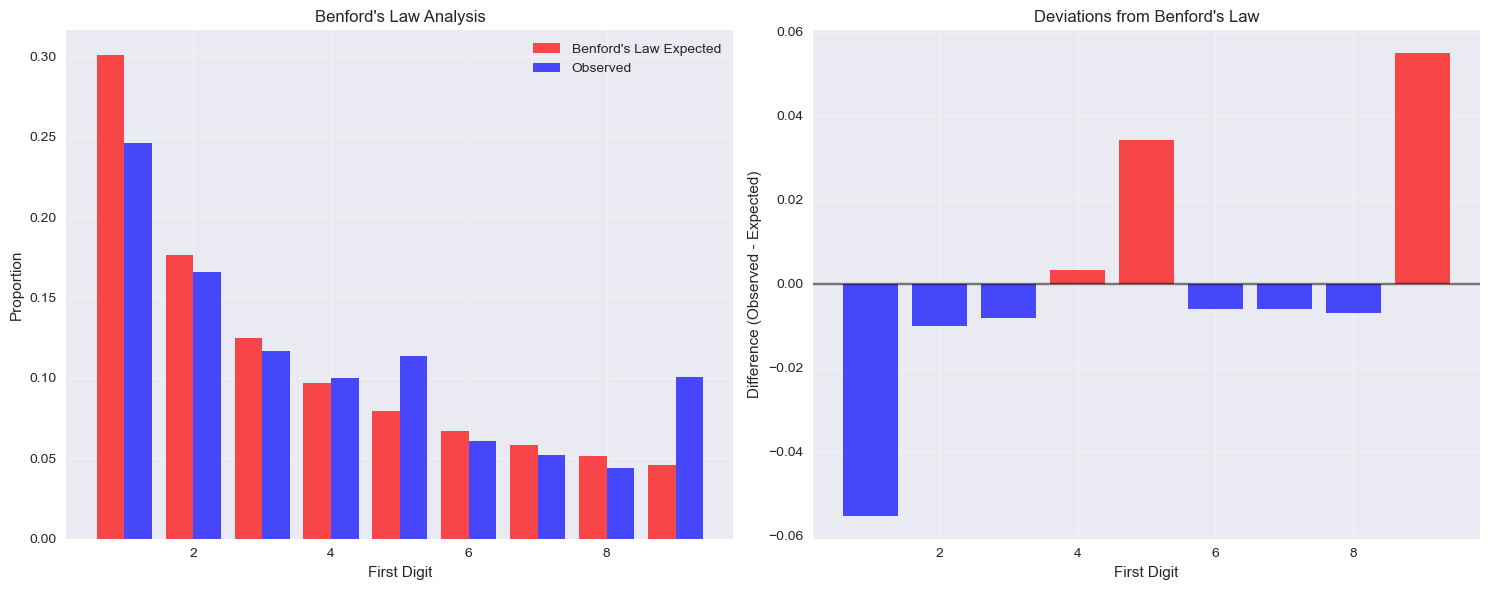


=== Benford's Law Analysis Results ===
Sample size: 7,634
Chi-squared statistic: 717.5071
P-value: 0.000000
Euclidean distance: 0.0867
Is anomalous (α=0.05): True

⚠️  ALERT: This dataset significantly deviates from Benford's Law!
   Further investigation with advanced clustering is warranted.


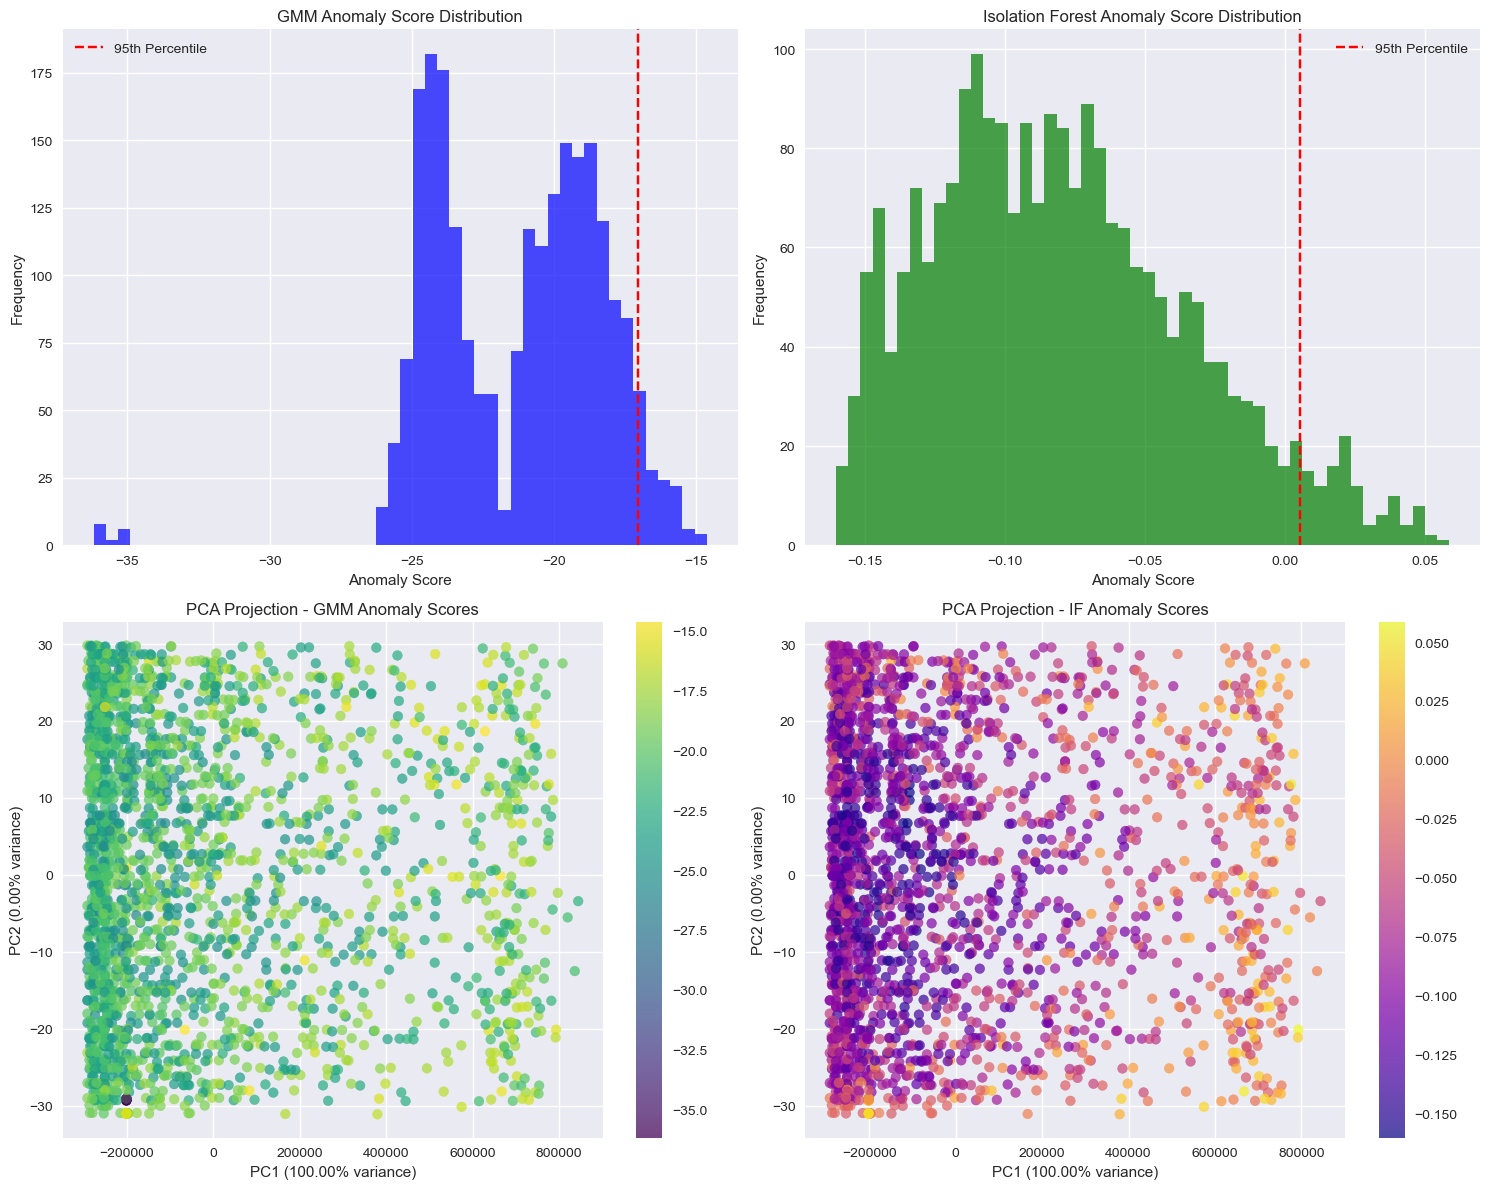

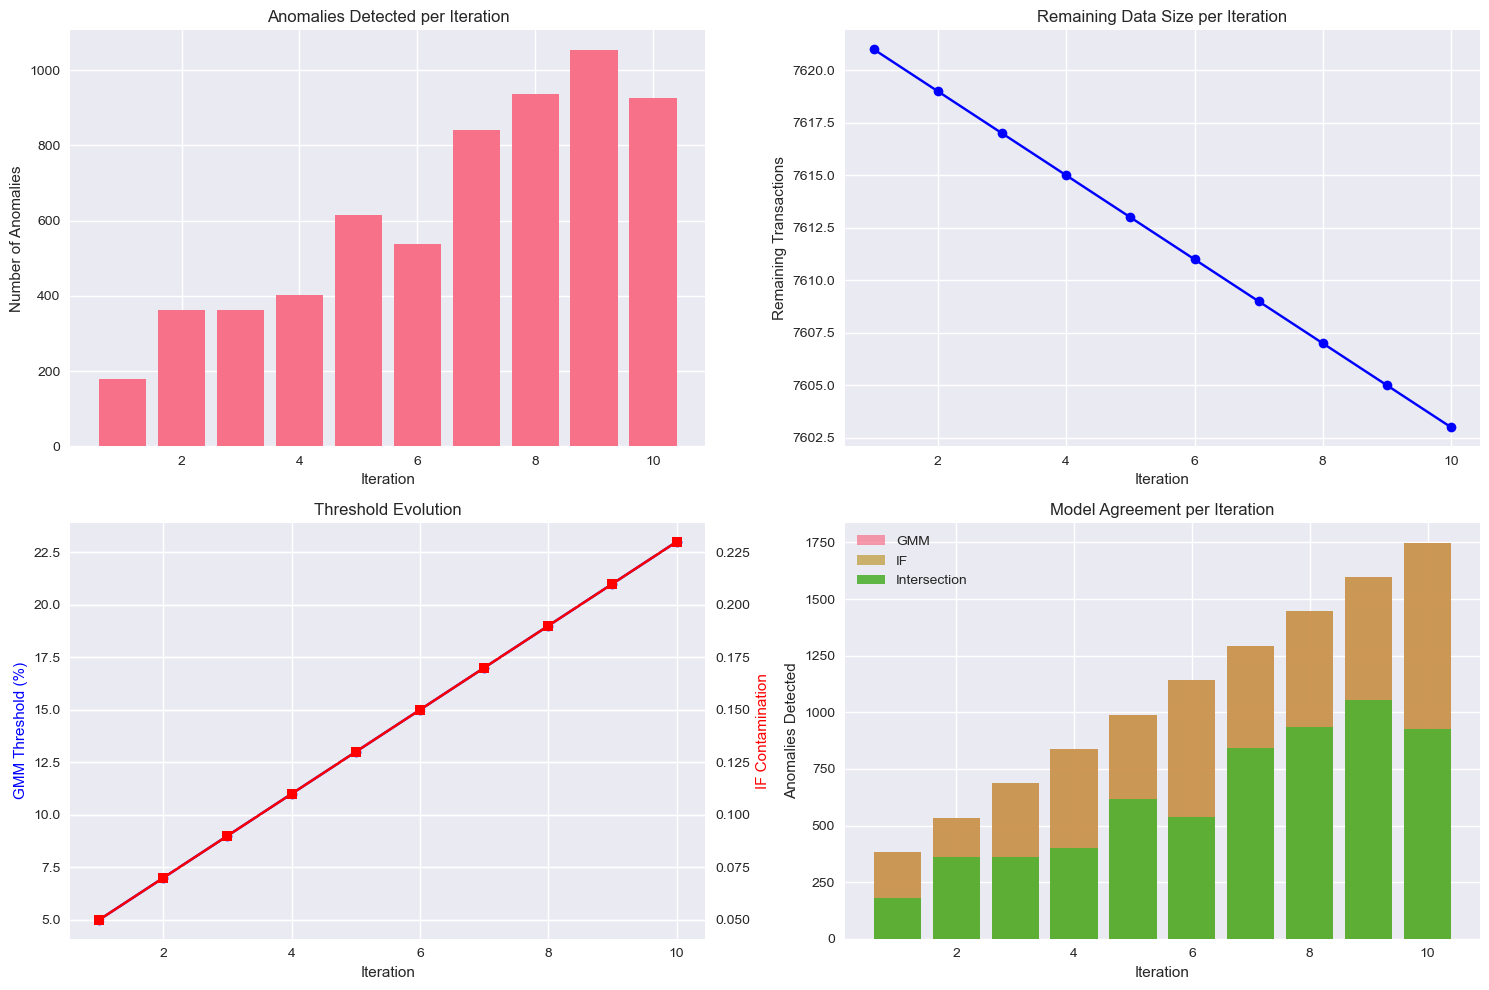

In [10]:
def create_comprehensive_visualizations(batch_data, eval_results, detector_results):
    """
    Create comprehensive visualization suite
    """
    # 1. Benford's Law Analysis
    benford_result = benford_analysis(batch_data)
    visualize_benford_analysis(benford_result)
    
    # 2. Anomaly Score Distributions
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # GMM scores
    axes[0, 0].hist(eval_results['gmm_results']['anomaly_scores'], bins=50, alpha=0.7, color='blue')
    axes[0, 0].axvline(np.percentile(eval_results['gmm_results']['anomaly_scores'], 95), 
                      color='red', linestyle='--', label='95th Percentile')
    axes[0, 0].set_title('GMM Anomaly Score Distribution')
    axes[0, 0].set_xlabel('Anomaly Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    
    # IF scores
    axes[0, 1].hist(eval_results['if_results']['anomaly_scores'], bins=50, alpha=0.7, color='green')
    axes[0, 1].axvline(np.percentile(eval_results['if_results']['anomaly_scores'], 95), 
                      color='red', linestyle='--', label='95th Percentile')
    axes[0, 1].set_title('Isolation Forest Anomaly Score Distribution')
    axes[0, 1].set_xlabel('Anomaly Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    
    # 3. PCA Projection
    feature_data = eval_results['X_test']
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(feature_data)
    
    # GMM PCA
    scatter = axes[1, 0].scatter(pca_data[:, 0], pca_data[:, 1], 
                                c=eval_results['gmm_results']['anomaly_scores'], 
                                cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, ax=axes[1, 0])
    axes[1, 0].set_title('PCA Projection - GMM Anomaly Scores')
    axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    
    # IF PCA
    scatter = axes[1, 1].scatter(pca_data[:, 0], pca_data[:, 1], 
                                c=eval_results['if_results']['anomaly_scores'], 
                                cmap='plasma', alpha=0.7)
    plt.colorbar(scatter, ax=axes[1, 1])
    axes[1, 1].set_title('PCA Projection - IF Anomaly Scores')
    axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Progressive Thresholding Results
    if detector_results['iteration_results']:
        iterations_df = pd.DataFrame(detector_results['iteration_results'])
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Anomalies detected per iteration
        axes[0, 0].bar(iterations_df['iteration'], iterations_df['intersection_anomalies'])
        axes[0, 0].set_title('Anomalies Detected per Iteration')
        axes[0, 0].set_xlabel('Iteration')
        axes[0, 0].set_ylabel('Number of Anomalies')
        
        # Remaining data size
        axes[0, 1].plot(iterations_df['iteration'], iterations_df['remaining_size'], 'bo-')
        axes[0, 1].set_title('Remaining Data Size per Iteration')
        axes[0, 1].set_xlabel('Iteration')
        axes[0, 1].set_ylabel('Remaining Transactions')
        
        # Threshold evolution
        ax_twin = axes[1, 0].twinx()
        line1 = axes[1, 0].plot(iterations_df['iteration'], iterations_df['gmm_threshold'], 'b-o', label='GMM Threshold')
        line2 = ax_twin.plot(iterations_df['iteration'], iterations_df['if_contamination'], 'r-s', label='IF Contamination')
        axes[1, 0].set_xlabel('Iteration')
        axes[1, 0].set_ylabel('GMM Threshold (%)', color='b')
        ax_twin.set_ylabel('IF Contamination', color='r')
        axes[1, 0].set_title('Threshold Evolution')
        
        # Model agreement
        axes[1, 1].bar(iterations_df['iteration'], iterations_df['gmm_anomalies'], alpha=0.7, label='GMM')
        axes[1, 1].bar(iterations_df['iteration'], iterations_df['if_anomalies'], alpha=0.7, label='IF')
        axes[1, 1].bar(iterations_df['iteration'], iterations_df['intersection_anomalies'], alpha=0.9, label='Intersection')
        axes[1, 1].set_title('Model Agreement per Iteration')
        axes[1, 1].set_xlabel('Iteration')
        axes[1, 1].set_ylabel('Anomalies Detected')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()

# Generate visualizations
print("Generating comprehensive visualizations...")
create_comprehensive_visualizations(representative_batch, eval_results, results)

## 8. Results Analysis and Interpretation

In [11]:
def analyze_detected_anomalies(anomalies_df, normal_df):
    """
    Comprehensive analysis of detected anomalies
    """
    if len(anomalies_df) == 0:
        print("No anomalies detected for analysis.")
        return
    
    print("\n=== Anomaly Characteristics Analysis ===")
    
    # Basic statistics
    print(f"Total anomalies detected: {len(anomalies_df)}")
    print(f"Normal transactions: {len(normal_df)}")
    print(f"Anomaly rate: {len(anomalies_df)/(len(anomalies_df)+len(normal_df))*100:.2f}%")
    
    # Amount analysis
    print(f"\nAmount Analysis:")
    print(f"Anomalous amounts - Mean: ${anomalies_df['Amount'].mean():.2f}, Median: ${anomalies_df['Amount'].median():.2f}")
    print(f"Normal amounts - Mean: ${normal_df['Amount'].mean():.2f}, Median: ${normal_df['Amount'].median():.2f}")
    print(f"Amount difference (anomaly/normal ratio): {anomalies_df['Amount'].mean()/normal_df['Amount'].mean():.2f}")
    
    # Top anomalous transactions
    print(f"\nTop 10 Anomalous Transactions by Amount:")
    top_anomalies = anomalies_df.nlargest(10, 'Amount')[['Amount', 'TransactionType', 'Location', 'Merchant']]
    print(top_anomalies.to_string())
    
    # Categorical analysis
    categorical_features = ['TransactionType', 'Location', 'Merchant']
    
    for feature in categorical_features:
        if feature in anomalies_df.columns:
            print(f"\n{feature} Distribution in Anomalies:")
            anomaly_dist = anomalies_df[feature].value_counts(normalize=True)
            normal_dist = normal_df[feature].value_counts(normalize=True)
            
            for category in anomaly_dist.index[:5]:  # Top 5
                anomaly_pct = anomaly_dist[category] * 100
                normal_pct = normal_dist.get(category, 0) * 100
                ratio = anomaly_pct / normal_pct if normal_pct > 0 else float('inf')
                print(f"  {category}: {anomaly_pct:.1f}% (vs {normal_pct:.1f}% normal) - Ratio: {ratio:.2f}")
    
    # Temporal analysis
    if 'Hour' in anomalies_df.columns:
        print(f"\nTemporal Patterns:")
        print(f"Most common hours for anomalies: {anomalies_df['Hour'].mode().values}")
        print(f"Most common hours for normal: {normal_df['Hour'].mode().values}")
    
    # Statistical tests
    print(f"\nStatistical Tests:")
    from scipy.stats import mannwhitneyu, ks_2samp
    
    # Mann-Whitney U test for amount differences
    stat, p_value = mannwhitneyu(anomalies_df['Amount'], normal_df['Amount'], alternative='two-sided')
    print(f"Mann-Whitney U test for amounts: p-value = {p_value:.6f}")
    print(f"Significant difference in amounts: {'Yes' if p_value < 0.05 else 'No'}")

# Analyze the detected anomalies
if len(results['anomalies']) > 0:
    analyze_detected_anomalies(results['anomalies'], results['normal'])
else:
    print("No anomalies were detected in this batch for detailed analysis.")


=== Anomaly Characteristics Analysis ===
Total anomalies detected: 31
Normal transactions: 7603
Anomaly rate: 0.41%

Amount Analysis:
Anomalous amounts - Mean: $198686.13, Median: $110018.27
Normal amounts - Mean: $292187.19, Median: $169269.01
Amount difference (anomaly/normal ratio): 0.68

Top 10 Anomalous Transactions by Amount:
                            Amount TransactionType    Location    Merchant
Timestamp                                                                 
2023-06-26 07:37:00  767200.174727       171882.45   172775.17  204317.475
2023-06-26 06:12:00  522362.630000       171882.45   172775.17   324875.01
2023-06-26 07:01:00  484979.120000       173219.18   172775.17   387283.43
2023-06-26 06:13:00  478592.000000       171882.45   172351.44  204317.475
2023-06-26 06:01:00  279459.140000       171882.45   172775.17   387283.43
2023-06-26 07:53:00  271125.690000       173219.18   172775.17  204317.475
2023-06-26 06:21:00  263758.180000      172235.295  172143.395   

In [12]:
# Final pipeline summary
def generate_pipeline_summary(detector_results, eval_results):
    """
    Generate comprehensive pipeline summary
    """
    print("\n" + "="*60)
    print("           ANOMALY DETECTION PIPELINE SUMMARY")
    print("="*60)
    
    print(f"\n📊 BATCH PROCESSING RESULTS:")
    print(f"   • Total transactions processed: {len(results['anomalies']) + len(results['normal'])}")
    print(f"   • Anomalies detected: {len(results['anomalies'])}")
    print(f"   • Normal transactions: {len(results['normal'])}")
    print(f"   • Anomaly rate: {len(results['anomalies'])/(len(results['anomalies'])+len(results['normal']))*100:.2f}%")
    print(f"   • Progressive iterations: {detector_results['iterations']}")
    
    print(f"\n🔍 ALGORITHM PERFORMANCE:")
    print(f"   • GMM anomalies detected: {eval_results['gmm_results']['anomalies'].sum()}")
    print(f"   • Isolation Forest anomalies detected: {eval_results['if_results']['anomalies'].sum()}")
    
    intersection = eval_results['gmm_results']['anomalies'] & eval_results['if_results']['anomalies']
    union = eval_results['gmm_results']['anomalies'] | eval_results['if_results']['anomalies']
    jaccard = intersection.sum() / union.sum() if union.sum() > 0 else 0
    
    print(f"   • Algorithm intersection: {intersection.sum()} anomalies")
    print(f"   • Jaccard similarity: {jaccard:.3f}")
    
    print(f"\n📈 STATISTICAL ANALYSIS:")
    benford_result = benford_analysis(representative_batch)
    print(f"   • Benford's Law p-value: {benford_result['p_value']:.6f}")
    print(f"   • Chi-squared statistic: {benford_result['chi_squared']:.4f}")
    print(f"   • Dataset anomalous: {'Yes' if benford_result['is_anomalous'] else 'No'}")
    
    print(f"\n💡 PRACTICAL IMPLICATIONS:")
    
    if benford_result['is_anomalous']:
        print(f"   • ⚠️  This dataset shows significant deviation from Benford's Law")
        print(f"   • 🔴 Recommended action: Full investigation warranted")
        print(f"   • 📋 Escalation: Forward to T1 support for detailed review")
    else:
        print(f"   • ✅ Dataset appears statistically normal")
        print(f"   • 🟢 Recommended action: Standard monitoring sufficient")
    
    anomaly_rate = len(results['anomalies'])/(len(results['anomalies'])+len(results['normal']))*100
    if anomaly_rate > 10:
        print(f"   • ⚠️  High anomaly rate detected ({anomaly_rate:.1f}%)")
        print(f"   • 🔍 Consider adjusting detection thresholds")
    elif anomaly_rate < 1:
        print(f"   • ℹ️  Low anomaly rate ({anomaly_rate:.1f}%)")
        print(f"   • ✅ System operating within normal parameters")
    
    print(f"\n🔧 PIPELINE CONFIGURATION:")
    print(f"   • Benford threshold: 0.05")
    print(f"   • Initial GMM threshold: 5%")
    print(f"   • Initial IF contamination: 0.05")
    print(f"   • Maximum iterations: 10")
    print(f"   • Maximum removal: 75%")
    
    print("\n" + "="*60)

generate_pipeline_summary(results, eval_results)


           ANOMALY DETECTION PIPELINE SUMMARY

📊 BATCH PROCESSING RESULTS:
   • Total transactions processed: 7634
   • Anomalies detected: 31
   • Normal transactions: 7603
   • Anomaly rate: 0.41%
   • Progressive iterations: 10

🔍 ALGORITHM PERFORMANCE:
   • GMM anomalies detected: 115
   • Isolation Forest anomalies detected: 138
   • Algorithm intersection: 56 anomalies
   • Jaccard similarity: 0.284

📈 STATISTICAL ANALYSIS:
   • Benford's Law p-value: 0.000000
   • Chi-squared statistic: 717.5071
   • Dataset anomalous: Yes

💡 PRACTICAL IMPLICATIONS:
   • ⚠️  This dataset shows significant deviation from Benford's Law
   • 🔴 Recommended action: Full investigation warranted
   • 📋 Escalation: Forward to T1 support for detailed review
   • ℹ️  Low anomaly rate (0.4%)
   • ✅ System operating within normal parameters

🔧 PIPELINE CONFIGURATION:
   • Benford threshold: 0.05
   • Initial GMM threshold: 5%
   • Initial IF contamination: 0.05
   • Maximum iterations: 10
   • Maximum remo

## 9. Export Results

In [13]:
# Export anomalies and results
if len(results['anomalies']) > 0:
    print("Exporting detected anomalies...")
    results['anomalies'].to_csv('./detected_anomalies.csv', index=True)
    print(f"Exported {len(results['anomalies'])} anomalies to detected_anomalies.csv")

# Export iteration results
if results['iteration_results']:
    iteration_df = pd.DataFrame(results['iteration_results'])
    iteration_df.to_csv('./iteration_results.csv', index=False)
    print(f"Exported {len(iteration_df)} iteration results to iteration_results.csv")

print("\n🎉 Pipeline execution completed successfully!")
print("📁 Results exported to CSV files for further analysis")

Exporting detected anomalies...
Exported 31 anomalies to detected_anomalies.csv
Exported 10 iteration results to iteration_results.csv

🎉 Pipeline execution completed successfully!
📁 Results exported to CSV files for further analysis
